# Au-наночастицы для ОДТ

Найти концентрацию сферических Au-наночастиц диаметром `100 нм`, необходимую для `3-кратной разницы сигнала` при `λ = 800 нм` в среде `n = 1.33`.

По приложенной схеме основной вариант расчёта принимается для `L = 1 мм`.

Разность сигнала в децибелах:

`Delta_S_dB = 10 * log10(3) ~= 4.77 dB`

## Что вычисляется

- `Cext`, `Csca`, `Cabs` для одной Au-сферы;
- концентрация `N` для 3-кратной разницы сигнала при `L = 1 мм`;
- разность сигнала в `dB`.

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, spherical_yn

plt.style.use('seaborn-v0_8-whitegrid')

wavelength_um = 0.800
medium_index = 1.33
diameter_nm = 100.0
radius_um = diameter_nm / 2 / 1000

# две соседние точки из Johnson & Christy вокруг 800 нм
jc_wavelength_um = np.array([0.7560, 0.8211])
jc_n = np.array([0.14, 0.16])
jc_k = np.array([4.542, 5.083])

# получение n и k золота именно на 800 нм
au_n = np.interp(wavelength_um, jc_wavelength_um, jc_n)
au_k = np.interp(wavelength_um, jc_wavelength_um, jc_k)
particle_index = complex(au_n, au_k)
relative_index = particle_index / medium_index

print(f'Au at 800 nm: n = {au_n:.6f}, k = {au_k:.6f}')
print(f'Medium refractive index: n_m = {medium_index:.2f}')
print(f'Relative index m = {relative_index:.6f}')

Au at 800 nm: n = 0.153518, k = 4.907653
Medium refractive index: n_m = 1.33
Relative index m = 0.115427+3.689965j


## Теория Ми

Сначала рассчитываются `Qext`, `Qsca`, `Qabs`, затем сечения:

`C_i = Q_i * pi * a^2`, где `i in {ext, sca, abs}`.

Для диффузионной модели также используется `g`.

In [ ]:
def mie_full(relative_index: complex, size_parameter: float):
    # выбор числа гармоник
    # усечение бесконечного ряда Ми
    # x + 4*x^(1/3) + 2 практическая оценка, сколько членов ряда нужно, чтобы сумма уже хорошо сошлась, +10 добавлено как запас по устойчивости
    n_max = int(round(size_parameter + 4 * size_parameter ** (1 / 3) + 2)) + 10
    n = np.arange(1, n_max + 1)
    # переход к аргументу внутри частицы
    mx = relative_index * size_parameter

    # сферические функции Бесселя и Неймана
    # _x - внешняя область, _mx - внутренняя область, _p - производная
    j_x = spherical_jn(n, size_parameter)
    j_x_p = spherical_jn(n, size_parameter, derivative=True)
    y_x = spherical_yn(n, size_parameter)
    y_x_p = spherical_yn(n, size_parameter, derivative=True)
    j_mx = spherical_jn(n, mx)
    j_mx_p = spherical_jn(n, mx, derivative=True)

    # функции Риккати-Бесселя
    psi_x = size_parameter * j_x
    psi_x_p = j_x + size_parameter * j_x_p
    psi_mx = mx * j_mx
    psi_mx_p = j_mx + mx * j_mx_p
    xi_x = size_parameter * (j_x + 1j * y_x)
    xi_x_p = (j_x + 1j * y_x) + size_parameter * (j_x_p + 1j * y_x_p)

    # коэффициенты Ми
    a_n = (relative_index * psi_mx * psi_x_p - psi_x * psi_mx_p) / (relative_index * psi_mx * xi_x_p - xi_x * psi_mx_p)
    b_n = (psi_mx * psi_x_p - relative_index * psi_x * psi_mx_p) / (psi_mx * xi_x_p - relative_index * xi_x * psi_mx_p)

    # коэффициентный множитель
    coeff = 2 * n + 1
    # эффективность экстинкции
    q_ext = (2 / size_parameter ** 2) * np.sum(coeff * np.real(a_n + b_n))
    # эффектинвоить рассеяния
    q_sca = (2 / size_parameter ** 2) * np.sum(coeff * (np.abs(a_n) ** 2 + np.abs(b_n) ** 2))
    # эффективность поглощения
    q_abs = q_ext - q_sca

    # расчёт фактора анизотропии
    sum1 = 0.0
    for idx in range(1, len(n)):
        ni = n[idx - 1]
        sum1 += (ni * (ni + 2) / (ni + 1)) * np.real(a_n[idx - 1] * np.conj(a_n[idx]) + b_n[idx - 1] * np.conj(b_n[idx])) # учитывается связь соседних порядков
    sum2 = np.sum(((2 * n + 1) / (n * (n + 1))) * np.real(a_n * np.conj(b_n))) # учитывается свзяь электрических и магнитных вкладов одного порядка
    g = (4 / (size_parameter ** 2 * q_sca)) * (sum1 + sum2) # средний косинус угла рассеяния

    return {
        'n': n,
        'a_n': a_n,
        'b_n': b_n,
        'Qext': float(q_ext),
        'Qsca': float(q_sca),
        'Qabs': float(q_abs),
        'g': float(g),
    }


size_parameter = 2 * math.pi * medium_index * radius_um / wavelength_um
mie = mie_full(relative_index, size_parameter)

geom_area_um2 = math.pi * radius_um ** 2
c_ext_um2 = mie['Qext'] * geom_area_um2
c_sca_um2 = mie['Qsca'] * geom_area_um2
c_abs_um2 = mie['Qabs'] * geom_area_um2

c_ext_cm2 = c_ext_um2 * 1e-8
c_sca_cm2 = c_sca_um2 * 1e-8
c_abs_cm2 = c_abs_um2 * 1e-8

print(f"Size parameter x = {size_parameter:.6f}")
print(f"Qext = {mie['Qext']:.6f}")
print(f"Qsca = {mie['Qsca']:.6f}")
print(f"Qabs = {mie['Qabs']:.6f}")
print(f"g    = {mie['g']:.6f}")
print()
print(f"Cext = {c_ext_um2:.6e} um^2 = {c_ext_cm2:.6e} cm^2")
print(f"Csca = {c_sca_um2:.6e} um^2 = {c_sca_cm2:.6e} cm^2")
print(f"Cabs = {c_abs_um2:.6e} um^2 = {c_abs_cm2:.6e} cm^2")

Size parameter x = 0.522290
Qext = 0.541421
Qsca = 0.468476
Qabs = 0.072945
g    = -0.047003

Cext = 4.252310e-03 um^2 = 4.252310e-11 cm^2
Csca = 3.679405e-03 um^2 = 3.679405e-11 cm^2
Cabs = 5.729050e-04 um^2 = 5.729050e-12 cm^2


## Модель A: проекционное ослабление

`I = I0 * exp(-N * Cext * L)`

Отсюда для 3-кратной разницы сигнала при `L = 1 мм`:

`N_A = ln(3) / (Cext * L)`

In [15]:
def concentration_projection(c_ext_cm2: float, thickness_cm: float) -> float:
    return math.log(3) / (c_ext_cm2 * thickness_cm)


thickness_mm = 1.0
thickness_cm = thickness_mm / 10
N_projection = concentration_projection(c_ext_cm2, thickness_cm)

print(f'L = {thickness_mm:.1f} mm -> N_A = {N_projection:.6e} particles/cm^3 = {N_projection:.6e} particles/mL')

print()
print(f'Analytical form: N_A = ln(3) / ({c_ext_cm2:.6e} * L_cm), where L_cm = {thickness_cm:.6f} cm')
print(f'dB difference = {10 * math.log10(3):.6f} dB')

L = 1.0 mm -> N_A = 2.583566e+11 particles/cm^3 = 2.583566e+11 particles/mL

Analytical form: N_A = ln(3) / (4.252310e-11 * L_cm), where L_cm = 0.100000 cm
dB difference = 4.771213 dB


## Модель B: диффузионная

`mu_eff = sqrt(3 * mu_a * (mu_a + mu_s_prime))`, `mu_a` - коэффициент поглощения, `mu_s_prime` - приведённый коэффициент рассеяния

`I ~ exp(-mu_eff * L)`

`Delta_mu_a = N * Cabs`
`Delta_mu_s_prime = N * Csca * (1 - g)`

`I0 / I = exp((mu_eff_new - mu_eff_0) * L) = 3`

In [ ]:
# даёт коэффициент ослабления
def concentration_to_delta_mu_mm_inv(N_cm3: float, cross_section_cm2: float) -> float:
    return N_cm3 * cross_section_cm2 / 10


# диффузионное приближение
def mu_eff(mu_a_mm, mu_sp_mm):
    return math.sqrt(3 * mu_a_mm * (mu_a_mm + mu_sp_mm))


def solve_concentration_diffusion(mu_a0_mm, mu_sp0_mm, thickness_mm, c_abs_cm2, c_sca_cm2, g_value):
    target = math.log(3) / thickness_mm
    mu_eff_0 = mu_eff(mu_a0_mm, mu_sp0_mm)

    # вычисляется, насколько частицы увеличивают эффективное ослабление
    def delta_mu_eff(N_cm3):
        d_mu_a = concentration_to_delta_mu_mm_inv(N_cm3, c_abs_cm2)
        d_mu_sp = concentration_to_delta_mu_mm_inv(N_cm3, c_sca_cm2 * (1 - g_value))
        return mu_eff(mu_a0_mm + d_mu_a, mu_sp0_mm + d_mu_sp) - mu_eff_0

    lo, hi = 0.0, 1e14
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        if delta_mu_eff(mid) < target:
            lo = mid
        else:
            hi = mid
    return hi


brain_cases = {
    'Case 1: mu_a=0.02, mu_s_prime=1.12 mm^-1': {'mu_a': 0.02, 'mu_sp': 1.12},
    'Case 2: mu_a=0.036, mu_s=22, g=0.9 -> mu_s_prime=2.2 mm^-1': {'mu_a': 0.036, 'mu_sp': 2.2},
}

N_diffusion = {}
for label, props in brain_cases.items():
    N_diffusion[label] = solve_concentration_diffusion(
        props['mu_a'],
        props['mu_sp'],
        thickness_mm,
        c_abs_cm2,
        c_sca_cm2,
        mie['g'],
    )

for label, value in N_diffusion.items():
    print(label)
    print(f'  L = {thickness_mm:.1f} mm -> N_B = {value:.6e} particles/mL')
    print()

Case 1: mu_a=0.02, mu_s_prime=1.12 mm^-1
  L = 1.0 mm -> N_B = 3.593433e+11 particles/mL

Case 2: mu_a=0.036, mu_s=22, g=0.9 -> mu_s_prime=2.2 mm^-1
  L = 1.0 mm -> N_B = 3.334705e+11 particles/mL



## График

Ниже показаны рассчитанные сечения для одной Au-сферы.

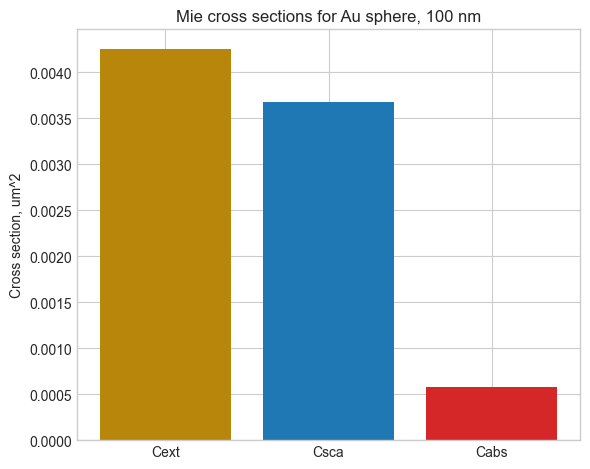

In [17]:
fig, ax = plt.subplots(figsize=(6, 4.8))

ax.bar(
    ['Cext', 'Csca', 'Cabs'],
    [c_ext_um2, c_sca_um2, c_abs_um2],
    color=['#b8860b', '#1f77b4', '#d62728'],
)
ax.set_ylabel('Cross section, um^2')
ax.set_title('Mie cross sections for Au sphere, 100 nm')

plt.tight_layout()

In [18]:
db_difference = 10 * math.log10(3)

print('WHAT MUST BE REPORTED')
print('1) Cext of one Au sphere at 800 nm in medium n=1.33')
print('2) Required nanoparticle concentration N for 3x signal difference')
print('3) Corresponding signal difference in dB')
print()
print('MAIN NUMERICAL RESULTS')
print(f'Cext = {c_ext_cm2:.6e} cm^2')
print(f'Csca = {c_sca_cm2:.6e} cm^2')
print(f'Cabs = {c_abs_cm2:.6e} cm^2')
print(f'dB difference = {db_difference:.6f} dB')
print()
print('PROJECTION MODEL')
print(f'L = {thickness_mm:.1f} mm -> N = {N_projection:.6e} particles/mL')
print()
print('DIFFUSION MODEL: representative literature ranges for brain tissue')
print(
    f'L = {thickness_mm:.1f} mm -> N = '
    f"{N_diffusion['Case 2: mu_a=0.036, mu_s=22, g=0.9 -> mu_s_prime=2.2 mm^-1']:.6e} ... "
    f"{N_diffusion['Case 1: mu_a=0.02, mu_s_prime=1.12 mm^-1']:.6e} particles/mL"
)
print()
print('DEFAULT SINGLE ANSWER FOR SUBMISSION USING THE ATTACHED SCHEME')
print('Interpretation of the figure: sample thickness along the probing beam is L = 1 mm')
print(f'Chosen thickness: L = {thickness_mm:.1f} mm')
print(f'Required concentration (projection model) = {N_projection:.6e} particles/mL')
print(f'Signal difference = {db_difference:.6f} dB')

WHAT MUST BE REPORTED
1) Cext of one Au sphere at 800 nm in medium n=1.33
2) Required nanoparticle concentration N for 3x signal difference
3) Corresponding signal difference in dB

MAIN NUMERICAL RESULTS
Cext = 4.252310e-11 cm^2
Csca = 3.679405e-11 cm^2
Cabs = 5.729050e-12 cm^2
dB difference = 4.771213 dB

PROJECTION MODEL
L = 1.0 mm -> N = 2.583566e+11 particles/mL

DIFFUSION MODEL: representative literature ranges for brain tissue
L = 1.0 mm -> N = 3.334705e+11 ... 3.593433e+11 particles/mL

DEFAULT SINGLE ANSWER FOR SUBMISSION USING THE ATTACHED SCHEME
Interpretation of the figure: sample thickness along the probing beam is L = 1 mm
Chosen thickness: L = 1.0 mm
Required concentration (projection model) = 2.583566e+11 particles/mL
Signal difference = 4.771213 dB


## Итог

- `Qext ≈ 0.541`
- `Cext ≈ 4.252e-11 см²`
- `Csca ≈ 3.679e-11 см²`
- `Cabs ≈ 5.729e-12 см²`
- `N = ln(3) / (Cext * L)`
- `Delta_S_dB ≈ 4.77 dB`

По схеме основной ответ принимается для `L = 1 мм`:

- `N ≈ 2.58e11 частиц/мл` в проекционной модели;
- `N ≈ (3.33e11 ... 3.59e11) частиц/мл` в диффузионной модели.